# Stroke Prevalence Prediction — Final Model

**Target:** PLACES_STROKE (census tract level)  
**Method:** XGBoost with RandomizedSearchCV hyperparameter tuning  
**Data:** EPA EQI 2011–2015 + CDC PLACES 2020, merged at census tract level  
**Random state:** 5003  
**Split:** 80/20 stratified by State

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# Color palette
BLUE = '#1f4e79'      # primary
GREY = '#6c757d'      # secondary
ORANGE = '#e67e22'    # accent
LIGHT_BLUE = '#d4e1f5'

plt.rcParams['axes.edgecolor'] = GREY
plt.rcParams['axes.labelcolor'] = '#212529'
plt.rcParams['xtick.color'] = GREY
plt.rcParams['ytick.color'] = GREY
plt.rcParams['axes.titlecolor'] = BLUE
plt.rcParams['font.family'] = 'sans-serif'

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)

---
## 1. Load and Select Variables

In [2]:
cdc_epa_data = pd.read_csv(
    "/Users/virginiaberthy/UVA-MSDS/DS 5003 - Healthcare DS - SP '26/Group Project/FINAL MODEL & RUN/EQI_2011_2015_PLACES_2020_merged_copy.csv"
)
print(f"Loaded: {cdc_epa_data.shape[0]:,} rows, {cdc_epa_data.shape[1]} columns")

Loaded: 70,962 rows, 73 columns


In [ ]:

variables_of_interest = [
    # EQI environmental + built environment
    'X_pop_dens', 'facilities_area', 'pest', 'time2work', 'crime_index','education_area', 'food_ratio', 'nindex_open', 'nata_sum', 'ozone','pm25', 'selfservice', 'RUCA_pri_cat',
    # Census/ACS demographics
    'poverty', 'bs_25yo', 'unemployment', 'rent_income_pct',
    # PLACES disease & behavior features (predictors, not targets)
    'PLACES_ACCESS2', 'PLACES_ARTHRITIS', 'PLACES_BINGE', 'PLACES_BPHIGH', 'PLACES_BPMED','PLACES_CASTHMA', 'PLACES_CERVICAL', 'PLACES_CHD', 'PLACES_CHECKUP','PLACES_CHOLSCREEN', 
    'PLACES_COLON_SCREEN', 'PLACES_COPD', 'PLACES_COREM','PLACES_COREW', 'PLACES_CSMOKING', 'PLACES_DENTAL', 'PLACES_DIABETES','PLACES_HIGHCHOL', 'PLACES_KIDNEY', 'PLACES_LPA', 
    'PLACES_MAMMOUSE','PLACES_MHLTH', 'PLACES_OBESITY', 'PLACES_PHLTH', 'PLACES_SLEEP','PLACES_TEETHLOST', 'PLACES_CANCER',]
target = 'PLACES_STROKE'

id_cols = ['tract_fips', 'State', 'County', 'StateAbbr', 'CountyName']

cdc_epa_selected = cdc_epa_data[variables_of_interest + [target] + id_cols]
print(f"Features: {len(variables_of_interest)}")
print(f"Target: {target}")

Features: 44
Target: PLACES_STROKE


In [30]:
csc_epa_selected = cdc_epa_selected.info()

<class 'pandas.DataFrame'>
RangeIndex: 70962 entries, 0 to 70961
Data columns (total 50 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   X_pop_dens           70962 non-null  float64
 1   facilities_area      70962 non-null  float64
 2   pest                 70962 non-null  float64
 3   time2work            70962 non-null  float64
 4   crime_index          70962 non-null  int64  
 5   education_area       70962 non-null  float64
 6   food_ratio           70962 non-null  float64
 7   nindex_open          70962 non-null  float64
 8   nata_sum             70962 non-null  float64
 9   ozone                70962 non-null  float64
 10  pm25                 70962 non-null  float64
 11  selfservice          70962 non-null  float64
 12  RUCA_pri_cat         70962 non-null  int64  
 13  poverty              70962 non-null  float64
 14  bs_25yo              70962 non-null  float64
 15  unemployment         70962 non-null  float64
 1

---
## 2. Train/Test Split

---
## 3. Hyperparameter Tuning (RandomizedSearchCV, 100 iterations, 5-fold CV)

In [4]:
cdc_epa_train, cdc_epa_test = train_test_split(
    cdc_epa_selected, test_size=0.2, random_state=5003,
    stratify=cdc_epa_selected['State']
)

feature_cols = variables_of_interest
num_cols = [c for c in feature_cols if cdc_epa_train[c].dtype in ['float64', 'int64']]

print(f"Train: {len(cdc_epa_train):,}  Test: {len(cdc_epa_test):,}")

Train: 56,769  Test: 14,193


In [5]:
xgb_params = {
    'n_estimators': [400, 500, 600, 800],
    'max_depth': [6, 7, 8, 10],
    'learning_rate': [0.03, 0.05, 0.07],
    'subsample': [0.75, 0.8, 0.85],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0.5, 1, 2, 5],
    'gamma': [0, 0.1, 0.3],
}

X_train = cdc_epa_train[feature_cols].copy()
y_train = cdc_epa_train[target]
X_test = cdc_epa_test[feature_cols].copy()
y_test = cdc_epa_test[target]

imputer = SimpleImputer(strategy='median')
X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = imputer.transform(X_test[num_cols])

scaler = MinMaxScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

xgb_cv = RandomizedSearchCV(
    XGBRegressor(random_state=5003),
    xgb_params, n_iter=100, cv=5, scoring='r2',
    random_state=5003, n_jobs=-1
)
xgb_cv.fit(X_train, y_train)

model = xgb_cv.best_estimator_
y_pred = model.predict(X_test)

rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)), 4)
r2 = round(r2_score(y_test, y_pred), 4)

print(f"\nSTROKE  R²: {r2}  RMSE: {rmse}")

/opt/miniconda3/envs/ml-course/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



STROKE  R²: 0.9965  RMSE: 0.0747


---
## 4. Model Performance & Best Hyperparameters

In [6]:
results_df = pd.DataFrame({
    'Metric': ['R²', 'RMSE', 'Test tracts', 'Train tracts'],
    'Value':  [r2, rmse, len(y_test), len(y_train)],
})

(results_df.style
    .format({'Value': lambda v: f'{v:,.4f}' if isinstance(v, float) else f'{v:,}'})
    .hide(axis='index')
    .set_caption('Stroke Model Performance')
    .set_table_styles([
        {'selector': 'caption', 'props': f'caption-side: top; font-size: 14pt; font-weight: bold; color: {BLUE}; padding: 8px;'},
        {'selector': 'th', 'props': f'background-color: {BLUE}; color: white; padding: 8px; text-align: left;'},
        {'selector': 'td', 'props': f'padding: 6px 12px; border-bottom: 1px solid {GREY};'},
    ]))

Metric,Value
R²,0.9965
RMSE,0.0747
Test tracts,"14,193.0000"
Train tracts,"56,769.0000"


In [7]:
best_params_df = pd.DataFrame(
    sorted(xgb_cv.best_params_.items()),
    columns=['Hyperparameter', 'Value']
)

(best_params_df.style
    .hide(axis='index')
    .set_caption('Best Hyperparameters (RandomizedSearchCV)')
    .set_table_styles([
        {'selector': 'caption', 'props': f'caption-side: top; font-size: 14pt; font-weight: bold; color: {BLUE}; padding: 8px;'},
        {'selector': 'th', 'props': f'background-color: {BLUE}; color: white; padding: 8px; text-align: left;'},
        {'selector': 'td', 'props': f'padding: 6px 12px; border-bottom: 1px solid {GREY};'},
    ]))

Hyperparameter,Value
colsample_bytree,0.800000
gamma,0.000000
learning_rate,0.030000
max_depth,8.000000
min_child_weight,3.000000
n_estimators,800.000000
reg_alpha,0.100000
reg_lambda,0.500000
subsample,0.800000


---
## 5. National Predicted vs Actual

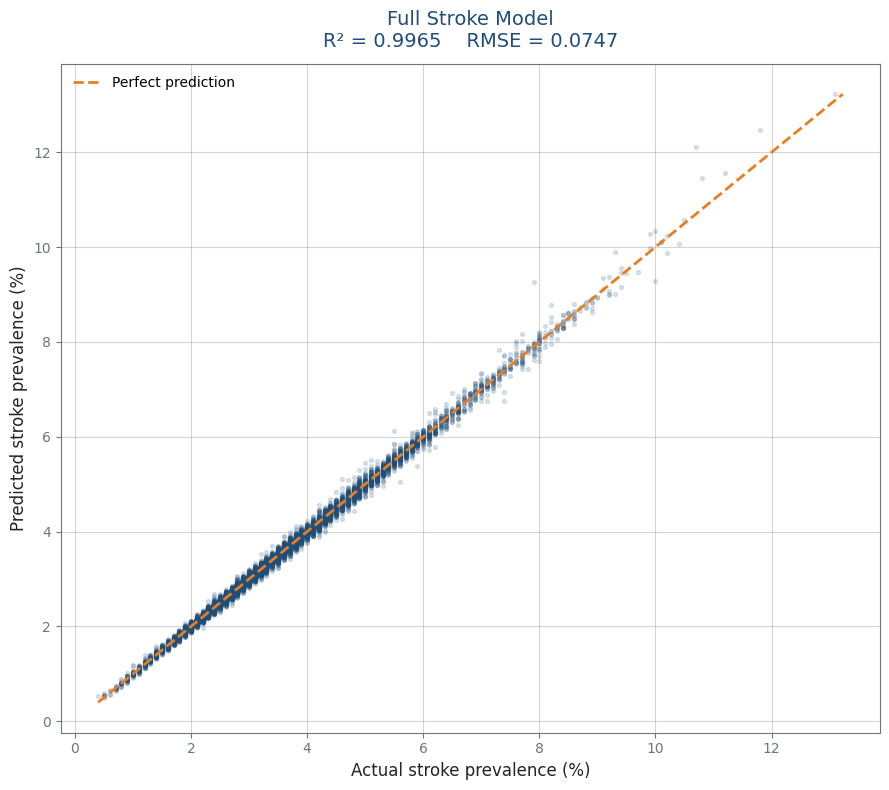

In [17]:
fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(y_test, y_pred, alpha=0.15, s=8, color=BLUE)
lo = min(y_test.min(), y_pred.min())
hi = max(y_test.max(), y_pred.max())
ax.plot([lo, hi], [lo, hi], color=ORANGE, lw=2, ls='--', label='Perfect prediction')
ax.set_xlabel('Actual stroke prevalence (%)', fontsize=12)
ax.set_ylabel('Predicted stroke prevalence (%)', fontsize=12)
ax.set_title(f'Full Stroke Model\nR² = {r2}    RMSE = {rmse}', fontsize=14, pad=12)
ax.legend(frameon=False, loc='upper left')
ax.grid(True, alpha=0.3, color=GREY)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('stroke_national_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. State-Level Evaluation

In [9]:
states_to_eval = {
    51: 'Virginia', 6: 'California', 36: 'New York', 48: 'Texas',
    13: 'Georgia', 18: 'Indiana', 10: 'Delaware', 56: 'Wyoming', 23: 'Maine',
}

state_results = []
y_test_arr = y_test.values
state_arr = cdc_epa_test['State'].values

for fips, name in states_to_eval.items():
    idx = np.where(state_arr == fips)[0]
    if len(idx) < 10:
        continue
    yt = y_test_arr[idx]
    yp = y_pred[idx]
    state_results.append({
        'State': name,
        'n_tracts': len(idx),
        'R²': round(r2_score(yt, yp), 4),
        'RMSE': round(np.sqrt(mean_squared_error(yt, yp)), 4),
    })

state_df = pd.DataFrame(state_results).sort_values('R²', ascending=False)

(state_df.style
    .background_gradient(subset=['R²'], cmap='Blues', vmin=0.9, vmax=1.0)
    .format({'R²': '{:.4f}', 'RMSE': '{:.4f}', 'n_tracts': '{:,}'})
    .hide(axis='index')
    .set_caption('Stroke Model Performance by State')
    .set_table_styles([
        {'selector': 'caption', 'props': f'caption-side: top; font-size: 14pt; font-weight: bold; color: {BLUE}; padding: 8px;'},
        {'selector': 'th', 'props': f'background-color: {BLUE}; color: white; padding: 8px; text-align: left;'},
        {'selector': 'td', 'props': f'padding: 6px 12px; border-bottom: 1px solid {GREY};'},
    ]))

State,n_tracts,R²,RMSE
Georgia,389,0.9977,0.0711
Virginia,369,0.9976,0.0603
Wyoming,26,0.9973,0.0429
Indiana,299,0.9962,0.0690
Delaware,42,0.9952,0.0710
Texas,"1,032",0.9943,0.0899
Maine,70,0.9943,0.0577
California,"1,588",0.9936,0.0709
New York,945,0.9930,0.0835


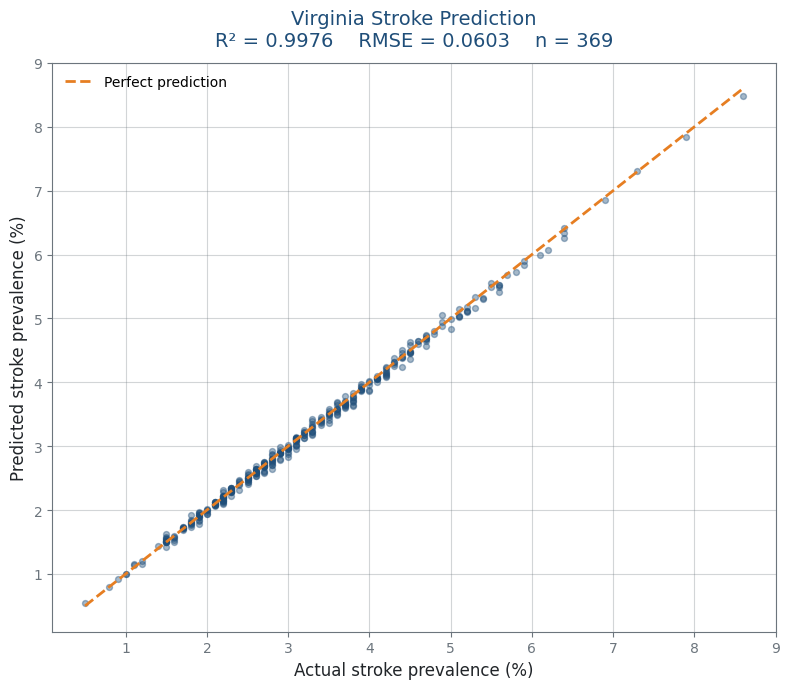

In [10]:
va_idx = np.where(cdc_epa_test['State'] == 51)[0]
y_test_va = y_test_arr[va_idx]
y_pred_va = y_pred[va_idx]
r2_va = round(r2_score(y_test_va, y_pred_va), 4)
rmse_va = round(np.sqrt(mean_squared_error(y_test_va, y_pred_va)), 4)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(y_test_va, y_pred_va, alpha=0.4, s=18, color=BLUE)
lo = min(y_test_va.min(), y_pred_va.min())
hi = max(y_test_va.max(), y_pred_va.max())
ax.plot([lo, hi], [lo, hi], color=ORANGE, lw=2, ls='--', label='Perfect prediction')
ax.set_xlabel('Actual stroke prevalence (%)', fontsize=12)
ax.set_ylabel('Predicted stroke prevalence (%)', fontsize=12)
ax.set_title(f'Virginia Stroke Prediction\nR² = {r2_va}    RMSE = {rmse_va}    n = {len(va_idx)}', fontsize=14, pad=12)
ax.legend(frameon=False, loc='upper left')
ax.grid(True, alpha=0.3, color=GREY)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('stroke_VA_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

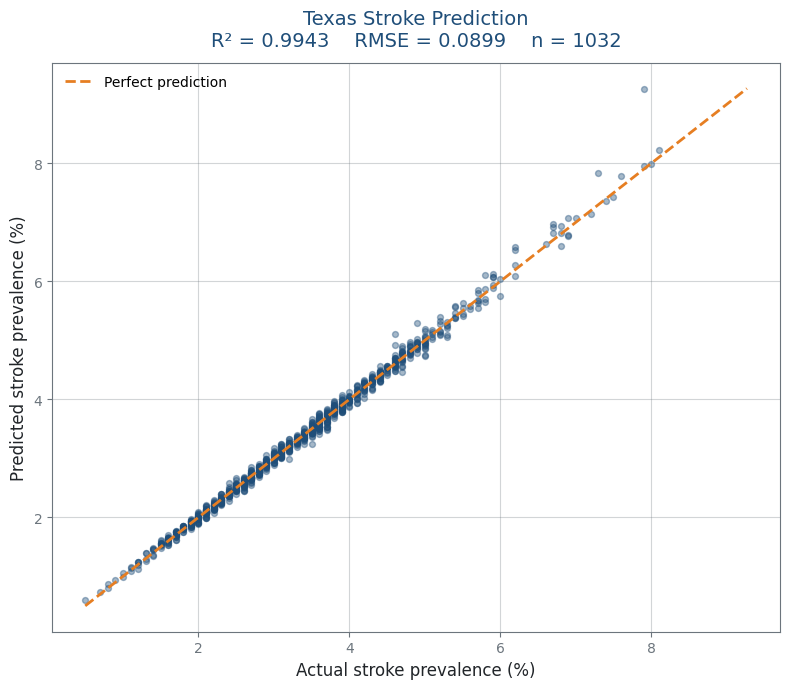

In [14]:
tx_idx = np.where(cdc_epa_test['State'] == 48)[0]
y_test_tx = y_test_arr[tx_idx]
y_pred_tx = y_pred[tx_idx]
r2_tx = round(r2_score(y_test_tx, y_pred_tx), 4)
rmse_tx = round(np.sqrt(mean_squared_error(y_test_tx, y_pred_tx)), 4)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(y_test_tx, y_pred_tx, alpha=0.4, s=18, color=BLUE)
lo = min(y_test_tx.min(), y_pred_tx.min())
hi = max(y_test_tx.max(), y_pred_tx.max())
ax.plot([lo, hi], [lo, hi], color=ORANGE, lw=2, ls='--', label='Perfect prediction')
ax.set_xlabel('Actual stroke prevalence (%)', fontsize=12)
ax.set_ylabel('Predicted stroke prevalence (%)', fontsize=12)
ax.set_title(f'Texas Stroke Prediction\nR² = {r2_tx}    RMSE = {rmse_tx}    n = {len(tx_idx)}', fontsize=14, pad=12)
ax.legend(frameon=False, loc='upper left')
ax.grid(True, alpha=0.3, color=GREY)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('stroke_TX_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7a. Virginia County-Level Predictions & Ranking

In [13]:
# Predict on all VA tracts (not just test set) for full county-level coverage
va_all = cdc_epa_selected[cdc_epa_selected['State'] == 51].copy()
X_va = va_all[feature_cols].copy()
X_va[num_cols] = imputer.transform(X_va[num_cols])
X_va[num_cols] = scaler.transform(X_va[num_cols])
va_all['pred_STROKE'] = model.predict(X_va)

# Aggregate to county level
va_county = (va_all.groupby(['County', 'CountyName'])
                   .agg(actual_STROKE=('PLACES_STROKE', 'mean'),
                        pred_STROKE=('pred_STROKE', 'mean'),
                        n_tracts=('tract_fips', 'count'))
                   .reset_index()
                   .round(4))

top20 = va_county.sort_values('pred_STROKE', ascending=False).head(20).reset_index(drop=True)
top20.index = top20.index + 1

(top20[['CountyName', 'pred_STROKE', 'actual_STROKE', 'n_tracts']]
    .style
    .background_gradient(subset=['pred_STROKE'], cmap='Blues')
    .format({'pred_STROKE': '{:.2f}%', 'actual_STROKE': '{:.2f}%', 'n_tracts': '{:,}'})
    .set_caption('Top 20 Virginia Counties by Predicted Stroke Prevalence')
    .set_table_styles([
        {'selector': 'caption', 'props': f'caption-side: top; font-size: 14pt; font-weight: bold; color: {BLUE}; padding: 8px;'},
        {'selector': 'th', 'props': f'background-color: {BLUE}; color: white; padding: 8px; text-align: left;'},
        {'selector': 'td', 'props': f'padding: 6px 12px; border-bottom: 1px solid {GREY};'},
    ]))

,CountyName,pred_STROKE,actual_STROKE,n_tracts
1,Emporia,6.27%,6.30%,2
2,Petersburg,6.01%,6.02%,11
3,Franklin City,5.64%,5.70%,2
4,Greensville,5.61%,5.60%,2
5,Martinsville,5.56%,5.54%,5
6,Danville,5.54%,5.55%,15
7,Brunswick,5.40%,5.42%,4
8,Northampton,5.38%,5.43%,3
9,Galax,5.32%,5.40%,2
10,Henry,5.28%,5.26%,14


## 7b. Texas County-Level Predictions & Ranking

In [15]:

# Predict on all TX tracts (not just test set) for full county-level coverage
tx_all = cdc_epa_selected[cdc_epa_selected['State'] == 48].copy()
X_tx = tx_all[feature_cols].copy()
X_tx[num_cols] = imputer.transform(X_tx[num_cols])
X_tx[num_cols] = scaler.transform(X_tx[num_cols])
tx_all['pred_STROKE'] = model.predict(X_tx)

# Aggregate to county level
tx_county = (tx_all.groupby(['County', 'CountyName'])
                   .agg(actual_STROKE=('PLACES_STROKE', 'mean'),
                        pred_STROKE=('pred_STROKE', 'mean'),
                        n_tracts=('tract_fips', 'count'))
                   .reset_index()
                   .round(4))

top20 = tx_county.sort_values('pred_STROKE', ascending=False).head(20).reset_index(drop=True)
top20.index = top20.index + 1

(top20[['CountyName', 'pred_STROKE', 'actual_STROKE', 'n_tracts']]
    .style
    .background_gradient(subset=['pred_STROKE'], cmap='Blues')
    .format({'pred_STROKE': '{:.2f}%', 'actual_STROKE': '{:.2f}%', 'n_tracts': '{:,}'})
    .set_caption('Top 20 Texas Counties by Predicted Stroke Prevalence')
    .set_table_styles([
        {'selector': 'caption', 'props': f'caption-side: top; font-size: 14pt; font-weight: bold; color: {BLUE}; padding: 8px;'},
        {'selector': 'th', 'props': f'background-color: {BLUE}; color: white; padding: 8px; text-align: left;'},
        {'selector': 'td', 'props': f'padding: 6px 12px; border-bottom: 1px solid {GREY};'},
    ]))

,CountyName,pred_STROKE,actual_STROKE,n_tracts
1,Hall,6.27%,6.30%,1
2,Cottle,5.91%,5.90%,1
3,San Augustine,5.78%,5.77%,3
4,Houston,5.66%,5.70%,6
5,Sabine,5.61%,5.60%,3
6,Real,5.56%,5.50%,1
7,Kinney,5.53%,5.50%,1
8,Marion,5.41%,5.45%,4
9,Presidio,5.33%,5.35%,2
10,Dimmit,5.24%,5.10%,2


---
## 8. Virginia County Heatmap

In [18]:
import plotly.express as px

va_county['fips'] = ('51' + va_county['County'].astype(int).astype(str).str.zfill(3))

fig = px.choropleth(
    va_county,
    geojson='https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json',
    locations='fips',
    color='pred_STROKE',
    color_continuous_scale='Blues',
    scope='usa',
    hover_name='CountyName',
    hover_data={'pred_STROKE': ':.2f', 'actual_STROKE': ':.2f', 'fips': False},
    labels={'pred_STROKE': 'Predicted stroke (%)'},
    title='Virginia Predicted Stroke Prevalence by County',
)
fig.update_geos(fitbounds='locations', visible=False)
fig.update_layout(
    title_font_color=BLUE,
    title_font_size=16,
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0},
)
fig.write_html('va_stroke_map.png')
fig.show()

In [16]:
import plotly.express as px

tx_county['fips'] = ('48' + tx_county['County'].astype(int).astype(str).str.zfill(3))

fig = px.choropleth(
    tx_county,
    geojson='https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json',
    locations='fips',
    color='pred_STROKE',
    color_continuous_scale='Blues',
    scope='usa',
    hover_name='CountyName',
    hover_data={'pred_STROKE': ':.2f', 'actual_STROKE': ':.2f', 'fips': False},
    labels={'pred_STROKE': 'Predicted stroke (%)'},
    title='Texas Predicted Stroke Prevalence by County',
)
fig.update_geos(fitbounds='locations', visible=False)
fig.update_layout(
    title_font_color=BLUE,
    title_font_size=16,
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0},
)
fig.write_html('tx_stroke_map.html')
fig.show()

In [19]:
# Predict on the FULL dataset, not just test
all_tracts = cdc_epa_selected.copy()
X_all = all_tracts[feature_cols].copy()
X_all[num_cols] = imputer.transform(X_all[num_cols])
X_all[num_cols] = scaler.transform(X_all[num_cols])
all_tracts['pred_STROKE'] = model.predict(X_all)

top10 = (all_tracts
    .nlargest(10, 'pred_STROKE')
    [['tract_fips', 'CountyName', 'StateAbbr', 'pred_STROKE', 'PLACES_STROKE']]
    .reset_index(drop=True))
top10.index = top10.index + 1
top10.columns = ['Tract', 'County', 'State', 'Predicted', 'Actual']
top10

,Tract,County,State,Predicted,Actual
1,39035112100,Cuyahoga,OH,14.0712,14.2000
2,36047035200,Kings,NY,13.9631,14.0000
3,39035113101,Cuyahoga,OH,13.2277,13.1000
4,42003552100,Allegheny,PA,12.9112,12.8000
5,1097000402,Mobile,AL,12.7162,12.7000
6,39035114700,Cuyahoga,OH,12.5199,12.5000
7,28047000100,Harrison,MS,12.4772,11.8000
8,12011110335,Broward,FL,12.1134,10.7000
9,39035152701,Cuyahoga,OH,11.9161,11.9000
10,17031340600,Cook,IL,11.8199,11.8000


In [21]:

# Predict on all OH tracts (not just test set) for full county-level coverage
oh_all = cdc_epa_selected[cdc_epa_selected['State'] == 39].copy()
X_oh = oh_all[feature_cols].copy()
X_oh[num_cols] = imputer.transform(X_oh[num_cols])
X_oh[num_cols] = scaler.transform(X_oh[num_cols])
oh_all['pred_STROKE'] = model.predict(X_oh)

# Aggregate to county level
oh_county = (oh_all.groupby(['County', 'CountyName'])
                .agg(actual_STROKE=('PLACES_STROKE', 'mean'),
                        pred_STROKE=('pred_STROKE', 'mean'),
                        n_tracts=('tract_fips', 'count'))
                .reset_index()
                .round(4))

top20 = oh_county.sort_values('pred_STROKE', ascending=False).head(20).reset_index(drop=True)
top20.index = top20.index + 1

(top20[['CountyName', 'pred_STROKE', 'actual_STROKE', 'n_tracts']]
    .style
    .background_gradient(subset=['pred_STROKE'], cmap='Blues')
    .format({'pred_STROKE': '{:.2f}%', 'actual_STROKE': '{:.2f}%', 'n_tracts': '{:,}'})
    .set_caption('Top 20 Ohio Counties by Predicted Stroke Prevalence')
    .set_table_styles([
        {'selector': 'caption', 'props': f'caption-side: top; font-size: 14pt; font-weight: bold; color: {BLUE}; padding: 8px;'},
        {'selector': 'th', 'props': f'background-color: {BLUE}; color: white; padding: 8px; text-align: left;'},
        {'selector': 'td', 'props': f'padding: 6px 12px; border-bottom: 1px solid {GREY};'},
    ]))

,CountyName,pred_STROKE,actual_STROKE,n_tracts
1,Mahoning,4.99%,5.00%,70
2,Cuyahoga,4.67%,4.67%,439
3,Morgan,4.67%,4.65%,4
4,Adams,4.65%,4.65%,6
5,Jefferson,4.49%,4.48%,23
6,Meigs,4.48%,4.47%,6
7,Monroe,4.41%,4.42%,4
8,Scioto,4.40%,4.40%,20
9,Noble,4.34%,4.30%,3
10,Vinton,4.32%,4.33%,3


In [22]:
# import plotly.express as px

oh_county['fips'] = ('39' + oh_county['County'].astype(int).astype(str).str.zfill(3))

fig = px.choropleth(
    oh_county,
    geojson='https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json',
    locations='fips',
    color='pred_STROKE',
    color_continuous_scale='Blues',
    scope='usa',
    hover_name='CountyName',
    hover_data={'pred_STROKE': ':.2f', 'actual_STROKE': ':.2f', 'fips': False},
    labels={'pred_STROKE': 'Predicted stroke (%)'},
    title='Ohio Predicted Stroke Prevalence by County',
)
fig.update_geos(fitbounds='locations', visible=False)
fig.update_layout(
    title_font_color=BLUE,
    title_font_size=16,
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0},
)
fig.write_html('oh_stroke_map.png')
fig.show()

In [23]:
# Make sure you have predictions on ALL tracts (not just test set)
all_tracts = cdc_epa_selected.copy()
X_all = all_tracts[feature_cols].copy()
X_all[num_cols] = imputer.transform(X_all[num_cols])
X_all[num_cols] = scaler.transform(X_all[num_cols])
all_tracts['pred_STROKE'] = model.predict(X_all)

# 1. Ohio statewide (population-weighted would be ideal, but simple mean works)
oh = all_tracts[all_tracts['State'] == 39]
ohio_actual = oh['PLACES_STROKE'].mean()
ohio_pred = oh['pred_STROKE'].mean()

# 2. Cuyahoga County (Ohio FIPS 39, county FIPS 035)
cuyahoga = all_tracts[(all_tracts['State'] == 39) & (all_tracts['County'] == 35)]
cuy_actual = cuyahoga['PLACES_STROKE'].mean()
cuy_pred = cuyahoga['pred_STROKE'].mean()

# 3. Highest single tract nationally
top_tract = all_tracts.nlargest(1, 'pred_STROKE').iloc[0]

print(f"Ohio (statewide):       actual {ohio_actual:.2f}%   predicted {ohio_pred:.2f}%   n={len(oh):,} tracts")
print(f"Cuyahoga County:        actual {cuy_actual:.2f}%   predicted {cuy_pred:.2f}%   n={len(cuyahoga):,} tracts")
print(f"Highest tract (US):     actual {top_tract['PLACES_STROKE']:.2f}%   predicted {top_tract['pred_STROKE']:.2f}%   tract {int(top_tract['tract_fips'])}")

Ohio (statewide):       actual 3.88%   predicted 3.88%   n=2,914 tracts
Cuyahoga County:        actual 4.67%   predicted 4.67%   n=439 tracts
Highest tract (US):     actual 14.20%   predicted 14.07%   tract 39035112100


In [27]:
import plotly.express as px
import pandas as pd

# Predict on ALL tracts
all_tracts = cdc_epa_selected.copy()
X_all = all_tracts[feature_cols].copy()
X_all[num_cols] = imputer.transform(X_all[num_cols])
X_all[num_cols] = scaler.transform(X_all[num_cols])
all_tracts['pred_STROKE'] = model.predict(X_all)

# Aggregate to state level
state_pred = (all_tracts.groupby('StateAbbr')
                        .agg(pred_STROKE=('pred_STROKE', 'mean'),
                             actual_STROKE=('PLACES_STROKE', 'mean'),
                             n_tracts=('tract_fips', 'count'))
                        .reset_index()
                        .round(3))

fig = px.choropleth(
    state_pred,
    locations='StateAbbr',
    locationmode='USA-states',
    color='pred_STROKE',
    color_continuous_scale='Blues',
    scope='usa',
    hover_name='StateAbbr',
    hover_data={'pred_STROKE': ':.2f', 'actual_STROKE': ':.2f', 'n_tracts': True},
    labels={'pred_STROKE': 'Predicted stroke (%)'},
    title='Predicted Stroke Prevalence by State',
)
fig.update_layout(
    title_font_color='#1F4E79',
    title_font_size=16,
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0},
)
fig.write_html('us_state_stroke_map.html')
# fig.write_image('us_state_stroke_map.png', scale=2, width=1200, height=700)
fig.show()

In [28]:
# getting number of rows in dataset
num_rows = cdc_epa_selected.shape[0]
print(f"Total number of rows in the dataset: {num_rows:,}")

Total number of rows in the dataset: 70,962


In [31]:
# Predict on all tracts (if not already done)
all_tracts = cdc_epa_selected.copy()
X_all = all_tracts[feature_cols].copy()
X_all[num_cols] = imputer.transform(X_all[num_cols])
X_all[num_cols] = scaler.transform(X_all[num_cols])
all_tracts['pred_STROKE'] = model.predict(X_all)

# Rank states by stroke prevalence
state_ranking = (all_tracts.groupby('StateAbbr')
                           .agg(actual_STROKE=('PLACES_STROKE', 'mean'),
                                pred_STROKE=('pred_STROKE', 'mean'),
                                n_tracts=('tract_fips', 'count'))
                           .sort_values('actual_STROKE', ascending=False)
                           .reset_index()
                           .round(3))
state_ranking.index = state_ranking.index + 1  # rank starts at 1
state_ranking

,StateAbbr,actual_STROKE,pred_STROKE,n_tracts
1,MS,4.5630,4.5550,651
2,AL,4.4390,4.4340,1165
3,LA,4.3690,4.3660,1110
4,AR,4.1620,4.1710,682
5,WV,4.0990,4.1110,483
6,FL,3.9400,3.9390,4122
7,TN,3.9390,3.9490,1461
8,OH,3.8840,3.8820,2914
9,OK,3.8730,3.8710,1034
10,SC,3.8680,3.8760,1078
